In [1]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("steam.csv")

df.head()

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819


In [3]:
df["rating_ratio"] = df["positive"] / (df["positive"] + df["negative"] + 1)

df["success"] = (
    (df["rating_ratio"] >= 0.8) &
    (df["ccu"] > df["ccu"].median())
).astype(int)

df["success"].value_counts()

success
0    6589
1    3411
Name: count, dtype: int64

In [4]:
columns_to_drop = [
    "appid",
    "name",
    "developer",
    "publisher",
    "score_rank",
    "owners",
    "positive",
    "negative",
    "rating_ratio",
    "ccu"
]

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df.head()

,userscore,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,success
0,0,33852,708,6645,301,0,0,0,1
1,0,10506,496,935,246,0,0,0,0
2,0,23165,717,5622,261,0,0,0,0
3,0,3854,835,2213,257,2999,2999,0,1
4,0,21244,736,4262,102,0,0,0,1


In [5]:
df.dtypes

userscore          int64
average_forever    int64
average_2weeks     int64
median_forever     int64
median_2weeks      int64
price              int64
initialprice       int64
discount           int64
success            int64
dtype: object

In [6]:
X = df.drop("success", axis=1)
y = df["success"]

print(X.shape)
print(y.shape)

(10000, 8)
(10000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
print(X_train[:5])

[[-0.01887186 -0.10805156 -0.18045177  0.01346832 -0.17221791  1.04985513
   0.88766324 -0.3739564 ]
 [-0.01887186 -0.21937101 -0.11448218 -0.15771904 -0.11213112 -0.11297832
   0.15262507  1.05910935]
 [-0.01887186  6.60963656  1.00378281  1.62168324 -0.02273369 -0.87459573
  -0.94919715 -0.3739564 ]
 [-0.01887186 -0.24059026 -0.17079768 -0.12072881 -0.16342472  0.66481094
   0.52014416 -0.3739564 ]
 [-0.01887186 -0.32546726 -0.18045177 -0.21148392 -0.17221791 -0.79835698
  -0.87642837 -0.3739564 ]]


In [11]:
model = Sequential([
    
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    
    Dense(32, activation='relu'),
    
    Dense(1, activation='sigmoid')
])

d:\projects\deepLearning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7089 - loss: 0.5601 - val_accuracy: 0.7256 - val_loss: 0.5427
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7405 - loss: 0.5257 - val_accuracy: 0.7569 - val_loss: 0.5201
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7502 - loss: 0.5114 - val_accuracy: 0.7625 - val_loss: 0.5133
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7570 - loss: 0.5048 - val_accuracy: 0.7613 - val_loss: 0.5115
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7572 - loss: 0.5004 - val_accuracy: 0.7650 - val_loss: 0.5093
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7595 - loss: 0.4947 - val_accuracy: 0.7669 - val_loss: 0.5128
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7606 - loss: 0.4929 - val_accuracy: 0.7675 - val_loss: 0.5101
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7642 - loss: 0.4906 - val_accuracy: 0.

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7660 - loss: 0.4814
Test Accuracy: 0.765999972820282
Test Loss: 0.48137930035591125


In [15]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1318
           1       0.70      0.55      0.62       682

    accuracy                           0.77      2000
   macro avg       0.75      0.71      0.72      2000
weighted avg       0.76      0.77      0.76      2000

[[1158  160]
 [ 308  374]]


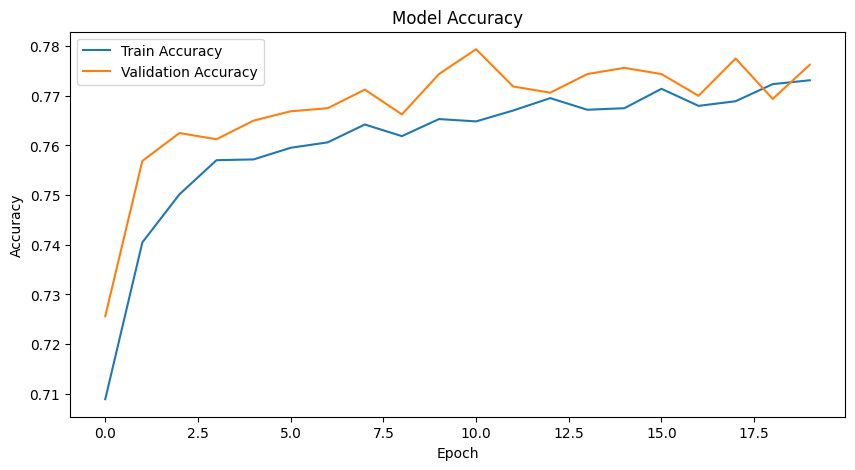

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

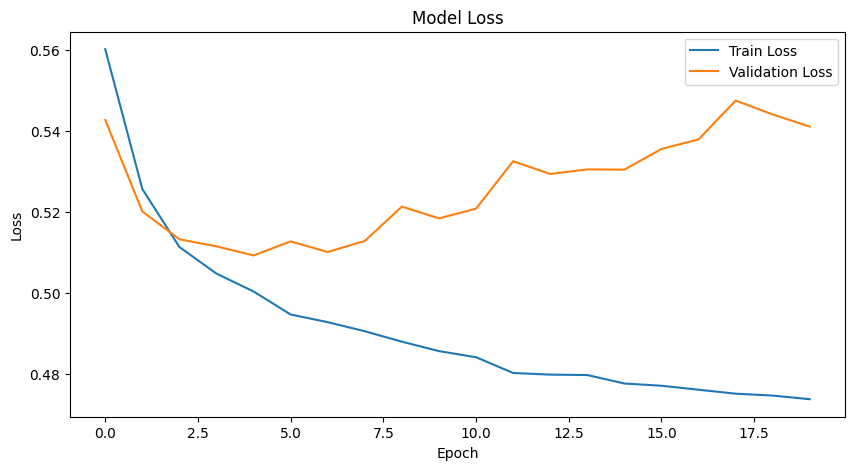

In [17]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [18]:
model.save("deep_learning_model.keras")
joblib.dump(scaler, "dl_scaler.pkl")
joblib.dump(list(X.columns), "dl_features.pkl")

['dl_features.pkl']